In [1]:
import pandas as pd

In [2]:
import glob

files = glob.glob('/content/*.csv')

len(files), files


(10,
 ['/content/2023.csv',
  '/content/2021.csv',
  '/content/2017.csv',
  '/content/2020.csv',
  '/content/2025.csv',
  '/content/2024.csv',
  '/content/2022.csv',
  '/content/2016.csv',
  '/content/2018.csv',
  '/content/2019.csv'])

In [3]:
df = pd.concat(
    [pd.read_csv(file) for file in files],
    ignore_index= True
)

In [4]:
df.head()

,Unnamed: 0,timestamp,symbol,open,high,low,close,previous_close,volume,turnover
0,0,2023-01-02,ADANIENT,3870.00,3874.00,3822.55,3841.20,3858.35,923051,3.551734e+09
1,1,2023-01-02,ADANIPORTS,823.00,826.75,816.30,822.30,818.10,2042294,1.678797e+09
2,2,2023-01-02,APOLLOHOSP,4488.00,4516.70,4446.00,4454.35,4477.60,246577,1.103054e+09
3,3,2023-01-02,ASIANPAINT,3087.90,3087.90,3021.00,3047.25,3087.90,1015990,3.090003e+09
4,4,2023-01-02,AXISBANK,932.25,945.00,931.80,941.60,933.75,3498198,3.284124e+09


In [5]:
df.shape

(112290, 10)

In [6]:
# Remove unnecessary index column
df = df.drop(columns=["Unnamed: 0"])

# Convert timestamp into datetime format
df["timestamp"] = pd.to_datetime(df["timestamp"])

# Sort data stock-wise and date-wise
df = df.sort_values(["symbol", "timestamp"]).reset_index(drop=True)

# Check the cleaned data
df.head()

,timestamp,symbol,open,high,low,close,previous_close,volume,turnover
0,2016-01-01,ADANIENT,83.60,90.70,82.35,90.10,83.40,5974246,5.218478e+08
1,2016-01-04,ADANIENT,89.50,92.05,84.25,85.10,90.10,5126957,4.510840e+08
2,2016-01-05,ADANIENT,85.65,89.60,84.20,88.60,85.10,5341021,4.656601e+08
3,2016-01-06,ADANIENT,88.00,88.95,85.30,86.25,88.60,3865229,3.362317e+08
4,2016-01-07,ADANIENT,84.90,84.90,78.00,79.95,86.25,4859987,3.965048e+08


In [7]:
print("Shape:", df.shape)

print("\nStocks:")
print(df["symbol"].nunique())

print("\nData Types:")
print(df.dtypes)

print("\nBasic Statistics:")
df.describe()

Shape: (112290, 9)

Stocks:
50

Data Types:
timestamp         datetime64[ns]
symbol                    object
open                     float64
high                     float64
low                      float64
close                    float64
previous_close           float64
volume                     int64
turnover                 float64
dtype: object

Basic Statistics:


,timestamp,open,high,low,close,previous_close,volume,turnover
count,112290,112290.000000,112290.000000,112290.000000,112290.000000,112290.000000,1.122900e+05,1.122900e+05
mean,2021-02-23 03:15:36.211595008,2183.218328,2208.112654,2155.983559,2181.581953,2181.143265,5.951661e+06,4.239945e+09
min,2016-01-01 00:00:00,57.800000,61.200000,50.000000,58.450000,58.450000,5.100000e+02,8.474456e+05
25%,2018-08-29 00:00:00,424.500000,430.200000,418.000000,424.162500,423.950000,8.817232e+05,1.238340e+09
50%,2021-03-19 00:00:00,1062.800000,1076.750000,1048.725000,1063.075000,1062.750000,2.478572e+06,2.481987e+09
75%,2023-08-30 00:00:00,2334.000000,2359.937500,2303.987500,2330.687500,2330.587500,7.085778e+06,4.993035e+09
max,2025-12-31 00:00:00,33399.950000,33480.000000,32468.100000,32861.950000,32861.950000,4.675740e+08,3.816391e+11
std,NaN,3535.621039,3574.667046,3491.052575,3531.786084,3531.609936,1.042083e+07,6.138356e+09


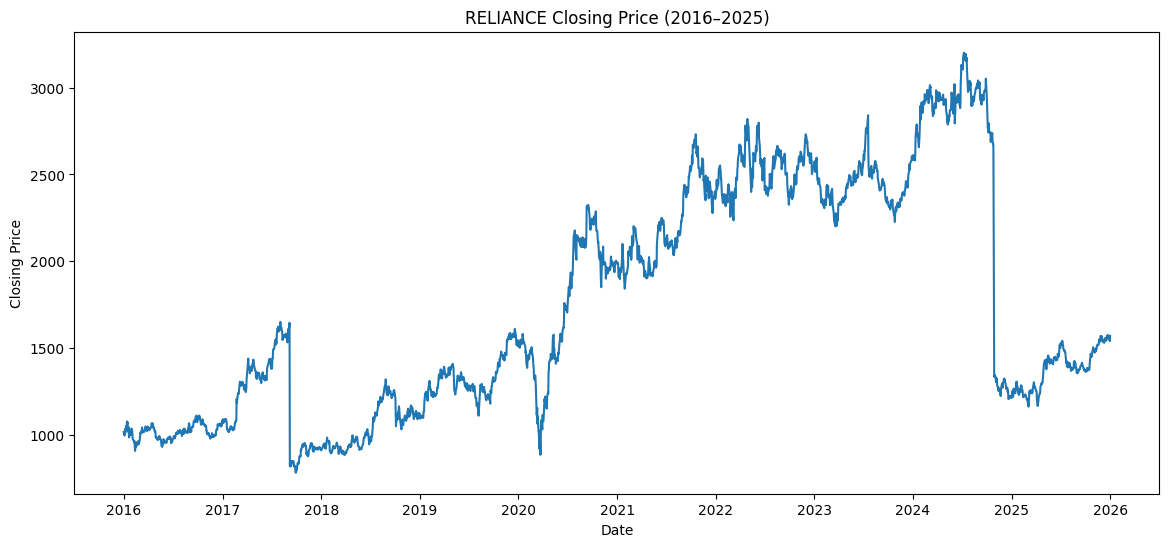

In [8]:
import matplotlib.pyplot as plt

reliance =df[df["symbol"] == "RELIANCE"]

plt.figure(figsize=(14, 6))
plt.plot(reliance["timestamp"], reliance["close"])

plt.title("RELIANCE Closing Price (2016–2025)")
plt.xlabel("Date")
plt.ylabel("Closing Price")
plt.show()

In [9]:
# Select Reliance data
reliance = df[df["symbol"] == "RELIANCE"].copy()

# Calculate daily percentage change in closing price
reliance["daily_return"] = reliance["close"].pct_change() * 100

# Show the biggest daily falls
reliance.sort_values("daily_return").head(10)[
    ["timestamp", "previous_close", "close", "daily_return"]
]

,timestamp,previous_close,close,daily_return
83673,2017-09-07,1645.40,818.10,-50.279567
85439,2024-10-28,2655.70,1334.35,-49.755243
84298,2020-03-23,1017.95,884.05,-13.153888
84289,2020-03-09,1271.00,1114.15,-12.340677
84451,2020-11-02,2054.50,1877.45,-8.617669
84293,2020-03-16,1105.30,1015.70,-8.106396
84291,2020-03-12,1153.55,1063.00,-7.849681
85123,2023-07-20,2841.85,2619.85,-7.811813
85339,2024-06-04,3020.65,2794.55,-7.485144
84863,2022-07-01,2595.65,2408.70,-7.202435


In [10]:
# Calculate daily return separately for each stock
df["daily_return"] = df.groupby("symbol")["close"].pct_change() * 100

# Find unusually large daily movements
abnormal_moves = df[abs(df["daily_return"]) > 20]

# Show the important columns
abnormal_moves[
    ["timestamp", "symbol", "previous_close", "close", "daily_return"]
].sort_values("daily_return")

,timestamp,symbol,previous_close,close,daily_return
75342,2024-01-05,NESTLEIND,27116.40,2666.40,-90.166836
59919,2017-01-04,JSWSTEEL,1644.55,163.05,-90.085434
33306,2020-08-24,EICHERMOT,21702.40,2176.45,-89.971386
19655,2025-06-16,BAJFINANCE,9331.00,938.00,-89.947487
17487,2016-09-08,BAJFINANCE,11393.30,1162.80,-89.794002
105039,2016-09-12,TRENT,2344.80,241.45,-89.702747
16498,2022-09-13,BAJAJFINSV,17138.05,1784.75,-89.586038
96549,2022-07-28,TATASTEEL,959.40,100.35,-89.540338
20088,2017-03-16,BEL,1569.65,165.15,-89.478546
90759,2025-01-10,SHRIRAMFIN,2809.85,532.00,-81.066605


In [11]:
# Count abnormal movements for each stock
abnormal_counts = (
    abnormal_moves
    .groupby("symbol")
    .size()
    .sort_values(ascending=False)
)

abnormal_counts

,0
symbol,
ADANIENT,8
BAJFINANCE,3
WIPRO,3
BEL,2
TRENT,2
BAJAJFINSV,2
NESTLEIND,2
POWERGRID,2
HDFCBANK,2


In [12]:
df[df["symbol"] == "ADANIENT"][
    ["timestamp", "open", "high", "low", "close", "previous_close"]
].loc[
    lambda x: abs(x["close"].pct_change()) > 0.20
]

,timestamp,open,high,low,close,previous_close
323,2017-04-26,150.20,151.55,117.20,118.55,149.95
664,2018-09-06,150.00,170.65,139.35,163.70,210.95
833,2019-05-20,131.20,154.90,128.10,151.95,119.30
1145,2020-08-25,252.00,322.40,250.00,307.55,248.70
1751,2023-02-01,2995.00,3010.75,1941.20,2135.35,2973.90
1752,2023-02-02,2348.85,2348.85,1494.75,1565.25,2135.35
1756,2023-02-08,1869.85,2222.15,1840.85,2164.25,1802.95
2197,2024-11-21,2539.35,2539.35,2155.05,2183.65,2821.50


In [13]:
# Check whether previous_close matches the previous trading day's close
adani = df[df["symbol"] == "ADANIENT"].copy()

adani["actual_previous_close"] = adani["close"].shift(1)

adani["difference"] = (
    adani["previous_close"] - adani["actual_previous_close"]
)

adani[
    ["timestamp", "previous_close", "actual_previous_close", "close", "difference"]
].loc[
    lambda x: x["difference"].abs() > 0.01
]

,timestamp,previous_close,actual_previous_close,close,difference
203,2016-11-01,67.00,66.90,66.75,0.10
940,2019-10-29,183.40,181.30,195.55,2.10
1007,2020-02-03,222.80,229.45,220.90,-6.65
1203,2020-11-17,371.25,368.60,394.30,2.65


In [14]:
# Get the next trading day's closing price for each stock
df["next_close"] = df.groupby("symbol")["close"].shift(-1)

# Create the target: 1 if next day's price goes up, otherwise 0
df["target"] = (df["next_close"] > df["close"]).astype(int)

In [15]:
df[["timestamp", "symbol", "close", "next_close", "target"]].head(10)

,timestamp,symbol,close,next_close,target
0,2016-01-01,ADANIENT,90.10,85.10,0
1,2016-01-04,ADANIENT,85.10,88.60,1
2,2016-01-05,ADANIENT,88.60,86.25,0
3,2016-01-06,ADANIENT,86.25,79.95,0
4,2016-01-07,ADANIENT,79.95,82.00,1
5,2016-01-08,ADANIENT,82.00,82.35,1
6,2016-01-11,ADANIENT,82.35,80.80,0
7,2016-01-12,ADANIENT,80.80,80.85,1
8,2016-01-13,ADANIENT,80.85,77.80,0
9,2016-01-14,ADANIENT,77.80,74.40,0


In [16]:
# Remove rows where the next trading day's price is not available
df = df.dropna(subset=["next_close"]).copy()

# Check the result
df[["timestamp", "symbol", "close", "next_close", "target"]].tail()

,timestamp,symbol,close,next_close,target
112284,2025-12-23,WIPRO,271.40,268.06,0
112285,2025-12-24,WIPRO,268.06,266.30,0
112286,2025-12-26,WIPRO,266.30,264.24,0
112287,2025-12-29,WIPRO,264.24,263.65,0
112288,2025-12-30,WIPRO,263.65,263.28,0


In [17]:
# Calculate 10-day moving average separately for each stock
df["ma_10"] = (
    df.groupby("symbol")["close"]
      .transform(lambda x: x.rolling(10).mean())
)

# Check the new feature
df[["timestamp", "symbol", "close", "ma_10"]].head(15)

,timestamp,symbol,close,ma_10
0,2016-01-01,ADANIENT,90.10,NaN
1,2016-01-04,ADANIENT,85.10,NaN
2,2016-01-05,ADANIENT,88.60,NaN
3,2016-01-06,ADANIENT,86.25,NaN
4,2016-01-07,ADANIENT,79.95,NaN
5,2016-01-08,ADANIENT,82.00,NaN
6,2016-01-11,ADANIENT,82.35,NaN
7,2016-01-12,ADANIENT,80.80,NaN
8,2016-01-13,ADANIENT,80.85,NaN
9,2016-01-14,ADANIENT,77.80,83.380


In [18]:
# Calculate 10-day rolling volatility for each stock
df["volatility_10"] = (
    df.groupby("symbol")["daily_return"]
      .transform(lambda x: x.rolling(10).std())
)

# Check the result
df[["timestamp", "symbol", "daily_return", "volatility_10"]].head(15)

,timestamp,symbol,daily_return,volatility_10
0,2016-01-01,ADANIENT,NaN,NaN
1,2016-01-04,ADANIENT,-5.549390,NaN
2,2016-01-05,ADANIENT,4.112808,NaN
3,2016-01-06,ADANIENT,-2.652370,NaN
4,2016-01-07,ADANIENT,-7.304348,NaN
5,2016-01-08,ADANIENT,2.564103,NaN
6,2016-01-11,ADANIENT,0.426829,NaN
7,2016-01-12,ADANIENT,-1.882210,NaN
8,2016-01-13,ADANIENT,0.061881,NaN
9,2016-01-14,ADANIENT,-3.772418,NaN


In [19]:
# Calculate 10-day average volume for each stock
df["avg_volume_10"] = (
    df.groupby("symbol")["volume"]
      .transform(lambda x: x.rolling(10).mean())
)

# Calculate today's volume relative to its 10-day average
df["volume_ratio"] = df["volume"] / df["avg_volume_10"]

# Check the new feature
df[["timestamp", "symbol", "volume", "avg_volume_10", "volume_ratio"]].head(15)

,timestamp,symbol,volume,avg_volume_10,volume_ratio
0,2016-01-01,ADANIENT,5974246,NaN,NaN
1,2016-01-04,ADANIENT,5126957,NaN,NaN
2,2016-01-05,ADANIENT,5341021,NaN,NaN
3,2016-01-06,ADANIENT,3865229,NaN,NaN
4,2016-01-07,ADANIENT,4859987,NaN,NaN
5,2016-01-08,ADANIENT,3492476,NaN,NaN
6,2016-01-11,ADANIENT,4147205,NaN,NaN
7,2016-01-12,ADANIENT,3916491,NaN,NaN
8,2016-01-13,ADANIENT,8071984,NaN,NaN
9,2016-01-14,ADANIENT,4641059,4943665.5,0.938789


In [20]:
# Calculate how far the current price is from its 10-day moving average
df["price_vs_ma10"] = (
    (df["close"] - df["ma_10"]) / df["ma_10"]
) * 100

# Check the feature
df[[
    "timestamp",
    "symbol",
    "close",
    "ma_10",
    "price_vs_ma10"
]].head(15)

,timestamp,symbol,close,ma_10,price_vs_ma10
0,2016-01-01,ADANIENT,90.10,NaN,NaN
1,2016-01-04,ADANIENT,85.10,NaN,NaN
2,2016-01-05,ADANIENT,88.60,NaN,NaN
3,2016-01-06,ADANIENT,86.25,NaN,NaN
4,2016-01-07,ADANIENT,79.95,NaN,NaN
5,2016-01-08,ADANIENT,82.00,NaN,NaN
6,2016-01-11,ADANIENT,82.35,NaN,NaN
7,2016-01-12,ADANIENT,80.80,NaN,NaN
8,2016-01-13,ADANIENT,80.85,NaN,NaN
9,2016-01-14,ADANIENT,77.80,83.380,-6.692252


In [21]:
# Calculate the intraday high-low range as a percentage of closing price
df["high_low_range"] = (
    (df["high"] - df["low"]) / df["close"]
) * 100

# Check the new feature
df[[
    "timestamp",
    "symbol",
    "high",
    "low",
    "close",
    "high_low_range"
]].head(10)

,timestamp,symbol,high,low,close,high_low_range
0,2016-01-01,ADANIENT,90.70,82.35,90.10,9.267481
1,2016-01-04,ADANIENT,92.05,84.25,85.10,9.165687
2,2016-01-05,ADANIENT,89.60,84.20,88.60,6.094808
3,2016-01-06,ADANIENT,88.95,85.30,86.25,4.231884
4,2016-01-07,ADANIENT,84.90,78.00,79.95,8.630394
5,2016-01-08,ADANIENT,83.00,80.65,82.00,2.865854
6,2016-01-11,ADANIENT,83.90,78.90,82.35,6.071645
7,2016-01-12,ADANIENT,83.75,79.50,80.80,5.259901
8,2016-01-13,ADANIENT,85.60,77.20,80.85,10.389610
9,2016-01-14,ADANIENT,81.00,77.35,77.80,4.691517


In [22]:
# Remove rows with missing values created by rolling features
df = df.dropna().copy()

# Check final dataset
print("Final shape:", df.shape)

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

Final shape: (111740, 18)

Missing values:
timestamp         0
symbol            0
open              0
high              0
low               0
close             0
previous_close    0
volume            0
turnover          0
daily_return      0
next_close        0
target            0
ma_10             0
volatility_10     0
avg_volume_10     0
volume_ratio      0
price_vs_ma10     0
high_low_range    0
dtype: int64


In [23]:
# Create training data from 2016 to 2024
train = df[df["timestamp"].dt.year <= 2024].copy()

# Create testing data from 2025
test = df[df["timestamp"].dt.year == 2025].copy()

# Check the size of both datasets
print("Train shape:", train.shape)
print("Test shape:", test.shape)

# Check the date ranges
print("Train dates:", train["timestamp"].min(), "to", train["timestamp"].max())
print("Test dates:", test["timestamp"].min(), "to", test["timestamp"].max())

Train shape: (99630, 18)
Test shape: (12110, 18)
Train dates: 2016-01-15 00:00:00 to 2024-12-31 00:00:00
Test dates: 2025-01-01 00:00:00 to 2025-12-30 00:00:00


In [24]:
# Features that the model will use
features = [
    "daily_return",
    "ma_10",
    "volatility_10",
    "volume_ratio",
    "price_vs_ma10",
    "high_low_range"
]

# Target column
target = "target"

# Training data
X_train = train[features]
y_train = train[target]

# Testing data
X_test = test[features]
y_test = test[target]

# Check shapes
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (99630, 6)
y_train: (99630,)
X_test: (12110, 6)
y_test: (12110,)


In [25]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [26]:
# Predict whether the stock will go UP or DOWN
y_pred = model.predict(X_test)

# Show first 20 predictions
print(y_pred[:20])

[0 0 0 0 1 0 0 0 1 1 1 1 1 1 1 1 1 0 1 0]


In [27]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Accuracy (%):", accuracy * 100)

Accuracy: 0.506523534269199
Accuracy (%): 50.6523534269199


In [28]:
print("Actual distribution:")
print(y_test.value_counts(normalize=True))

print("\nPredicted distribution:")
print(pd.Series(y_pred).value_counts(normalize=True))

Actual distribution:
target
1    0.50256
0    0.49744
Name: proportion, dtype: float64

Predicted distribution:
1    0.539884
0    0.460116
Name: proportion, dtype: float64


In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2810 3214]
 [2762 3324]]


In [30]:
# Get the importance of each feature from the Random Forest
feature_importance = pd.Series(
    model.feature_importances_,
    index=features
).sort_values(ascending=False)

print(feature_importance)

price_vs_ma10     0.167163
daily_return      0.167021
volume_ratio      0.166982
high_low_range    0.166551
ma_10             0.166153
volatility_10     0.166132
dtype: float64


In [31]:
# Create one row for each stock using average market behavior
stock_summary = df.groupby("symbol").agg({
    "daily_return": "mean",
    "volatility_10": "mean",
    "volume_ratio": "mean",
    "price_vs_ma10": "mean",
    "high_low_range": "mean"
}).reset_index()

# Check the result
print("Shape:", stock_summary.shape)

stock_summary.head()

Shape: (50, 6)


,symbol,daily_return,volatility_10,volume_ratio,price_vs_ma10,high_low_range
0,ADANIENT,0.187505,2.672559,1.016126,0.682697,4.134570
1,ADANIPORTS,0.103453,2.058007,1.017405,0.366017,3.122788
2,APOLLOHOSP,0.085136,1.745743,1.012524,0.319960,2.801812
3,ASIANPAINT,0.057616,1.386331,1.012051,0.224561,2.158657
4,AXISBANK,0.068183,1.749154,1.006893,0.227075,2.578532


In [32]:
from sklearn.preprocessing import StandardScaler

# Select features for clustering
cluster_features = [
    "daily_return",
    "volatility_10",
    "volume_ratio",
    "price_vs_ma10",
    "high_low_range"
]

# Create the scaler
scaler = StandardScaler()

# Scale the stock features
X_cluster = scaler.fit_transform(stock_summary[cluster_features])

# Check the shape
print("Scaled data shape:", X_cluster.shape)

Scaled data shape: (50, 5)


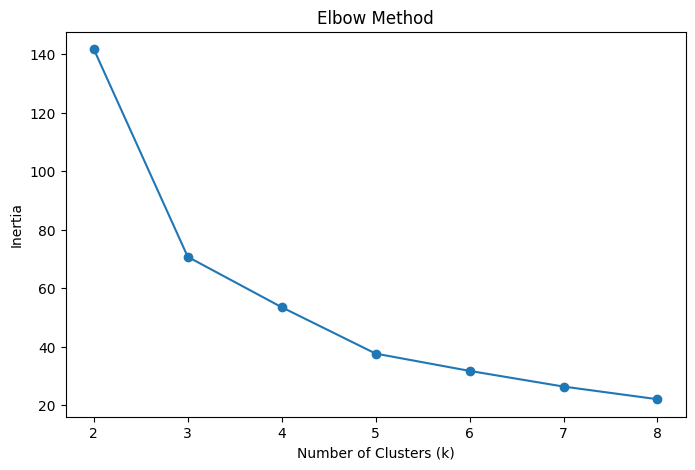

In [33]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Store the within-cluster error for different values of k
inertia = []

# Try different numbers of clusters
for k in range(2, 9):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_cluster)

    inertia.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(range(2, 9), inertia, marker="o")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [34]:
from sklearn.cluster import KMeans

# Create K-Means model with 4 clusters
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Train K-Means on the scaled stock data
kmeans.fit(X_cluster)

# Assign each stock to its cluster
stock_summary["cluster"] = kmeans.labels_

# Check the result
print(stock_summary[["symbol", "cluster"]].head(10))

       symbol  cluster
0    ADANIENT        3
1  ADANIPORTS        1
2  APOLLOHOSP        1
3  ASIANPAINT        0
4    AXISBANK        1
5  BAJAJ-AUTO        0
6  BAJAJFINSV        1
7  BAJFINANCE        1
8         BEL        1
9  BHARTIARTL        1


In [35]:
# Calculate the average behavior of each cluster
cluster_profile = stock_summary.groupby("cluster")[cluster_features].mean()

# Display the cluster profiles
print(cluster_profile)

         daily_return  volatility_10  volume_ratio  price_vs_ma10  \
cluster                                                             
0            0.048654       1.506854      1.011464       0.154277   
1            0.075306       1.912431      1.012901       0.202619   
2           -0.308880       1.257078      1.085910      -1.627133   
3            0.157282       2.299087      1.015672       0.571714   

         high_low_range  
cluster                  
0              2.261656  
1              2.787243  
2              1.953438  
3              3.604827  


In [36]:
# Create stock-level behavior summary using training data only
stock_summary_train = train.groupby("symbol").agg({
    "daily_return": "mean",
    "volatility_10": "mean",
    "volume_ratio": "mean",
    "price_vs_ma10": "mean",
    "high_low_range": "mean"
}).reset_index()

# Check the result
print("Shape:", stock_summary_train.shape)

stock_summary_train.head()

Shape: (48, 6)


,symbol,daily_return,volatility_10,volume_ratio,price_vs_ma10,high_low_range
0,ADANIENT,0.212406,2.765374,1.018043,0.776764,4.301938
1,ADANIPORTS,0.105935,2.121584,1.019137,0.365708,3.208270
2,APOLLOHOSP,0.095659,1.806395,1.012343,0.360439,2.914833
3,ASIANPAINT,0.054566,1.406141,1.011202,0.208462,2.190367
4,AXISBANK,0.067722,1.805782,1.007771,0.223514,2.665964


In [37]:
# Find stocks present in the full dataset
all_stocks = set(df["symbol"].unique())

# Find stocks available in training data
train_stocks = set(train["symbol"].unique())

# Find stocks missing from training data
missing_stocks = all_stocks - train_stocks

print("Stocks missing from training data:")
print(missing_stocks)

Stocks missing from training data:
{'ETERNAL', 'TMPV'}


In [38]:
# Features used for stock clustering
cluster_features = [
    "daily_return",
    "volatility_10",
    "volume_ratio",
    "price_vs_ma10",
    "high_low_range"
]

# Scale the training stock summaries
scaler_cluster = StandardScaler()

X_cluster_train = scaler_cluster.fit_transform(
    stock_summary_train[cluster_features]
)

print("Scaled training data shape:", X_cluster_train.shape)

Scaled training data shape: (48, 5)


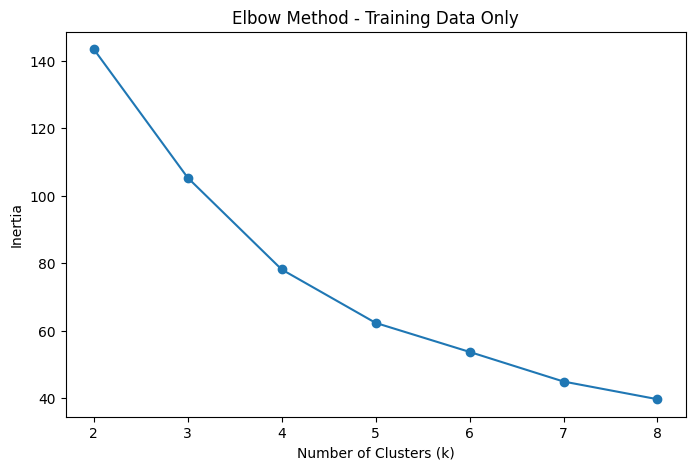

In [39]:
# Store inertia values for different numbers of clusters
inertia_train = []

# Try different values of k
for k in range(2, 9):

    # Create K-Means model
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    # Fit K-Means on training-only stock data
    kmeans.fit(X_cluster_train)

    # Store the inertia
    inertia_train.append(kmeans.inertia_)

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 9),
    inertia_train,
    marker="o"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method - Training Data Only")

plt.show()

In [40]:
# Create the final K-Means model with 4 clusters
kmeans_train = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

# Fit K-Means using training-only stock behavior
kmeans_train.fit(X_cluster_train)

# Assign each training stock to a cluster
stock_summary_train["cluster"] = kmeans_train.labels_

# Check the cluster assignments
print(stock_summary_train[["symbol", "cluster"]].head(10))

       symbol  cluster
0    ADANIENT        2
1  ADANIPORTS        1
2  APOLLOHOSP        1
3  ASIANPAINT        0
4    AXISBANK        1
5  BAJAJ-AUTO        0
6  BAJAJFINSV        3
7  BAJFINANCE        3
8         BEL        3
9  BHARTIARTL        1


In [41]:
# Create a mapping from stock symbol to its learned cluster
cluster_map = stock_summary_train.set_index("symbol")["cluster"]

# Add the cluster information to the training data
train["cluster"] = train["symbol"].map(cluster_map)

# Check the result
print(train[["symbol", "cluster"]].head(10))

# Check for missing clusters
print("\nMissing clusters:", train["cluster"].isna().sum())

      symbol  cluster
10  ADANIENT        2
11  ADANIENT        2
12  ADANIENT        2
13  ADANIENT        2
14  ADANIENT        2
15  ADANIENT        2
16  ADANIENT        2
17  ADANIENT        2
18  ADANIENT        2
19  ADANIENT        2

Missing clusters: 0


In [42]:
# Add the learned training clusters to the 2025 test data
test["cluster"] = test["symbol"].map(cluster_map)

# Check how many test rows received a cluster
print("Missing clusters in test:", test["cluster"].isna().sum())

# Check which stocks have missing clusters
print("\nStocks without a cluster:")
print(test.loc[test["cluster"].isna(), "symbol"].unique())

Missing clusters in test: 206

Stocks without a cluster:
['ETERNAL' 'TMPV']


In [43]:
# Remove test rows whose stocks were not present during training
test_clustered = test.dropna(subset=["cluster"]).copy()

# Check the new test size
print("Original test rows:", len(test))
print("Test rows with cluster:", len(test_clustered))
print("Removed rows:", len(test) - len(test_clustered))

Original test rows: 12110
Test rows with cluster: 11904
Removed rows: 206


In [44]:
# Add the cluster feature to our existing feature list
features_with_cluster = features + ["cluster"]

# Create training data with the new cluster feature
X_train_cluster = train[features_with_cluster]
y_train_cluster = train["target"]

# Create testing data using only stocks with a valid cluster
X_test_cluster = test_clustered[features_with_cluster]
y_test_cluster = test_clustered["target"]

# Check the shapes
print("X_train_cluster:", X_train_cluster.shape)
print("X_test_cluster:", X_test_cluster.shape)

X_train_cluster: (99630, 7)
X_test_cluster: (11904, 7)


In [45]:
from sklearn.ensemble import RandomForestClassifier

# Create a new Random Forest model
model_cluster = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train the model using the cluster feature
model_cluster.fit(X_train_cluster, y_train_cluster)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [46]:
# Predict UP/DOWN using the cluster-enhanced model
y_pred_cluster = model_cluster.predict(X_test_cluster)

# Show first 20 predictions
print(y_pred_cluster[:20])

[0 0 1 1 1 0 0 1 1 1 1 1 1 1 1 1 1 0 0 0]


In [47]:
from sklearn.metrics import accuracy_score

accuracy_cluster = accuracy_score(
    y_test_cluster,
    y_pred_cluster
)

print("Accuracy with Cluster:", accuracy_cluster)
print("Accuracy (%):", accuracy_cluster * 100)

Accuracy with Cluster: 0.5084005376344086
Accuracy (%): 50.840053763440864


In [48]:
# Predict on the same test rows used by the cluster model
y_pred_original_same_test = model.predict(
    test_clustered[features]
)

# Calculate accuracy on the same test rows
accuracy_original_same_test = accuracy_score(
    test_clustered["target"],
    y_pred_original_same_test
)

print("Original Model Accuracy:", accuracy_original_same_test)
print("Original Model Accuracy (%):", accuracy_original_same_test * 100)

print("Cluster Model Accuracy:", accuracy_cluster * 100)

Original Model Accuracy: 0.506888440860215
Original Model Accuracy (%): 50.688844086021504
Cluster Model Accuracy: 50.840053763440864


In [49]:
from sklearn.metrics import confusion_matrix, classification_report

# Create confusion matrix for the original Random Forest
cm_original = confusion_matrix(
    y_test_cluster,
    y_pred_original_same_test
)

# Display confusion matrix
print("Confusion Matrix:")
print(cm_original)

# Display precision, recall and F1-score
print("\nClassification Report:")
print(
    classification_report(
        y_test_cluster,
        y_pred_original_same_test
    )
)

Confusion Matrix:
[[2754 3166]
 [2704 3280]]

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.47      0.48      5920
           1       0.51      0.55      0.53      5984

    accuracy                           0.51     11904
   macro avg       0.51      0.51      0.51     11904
weighted avg       0.51      0.51      0.51     11904



In [50]:
# Recalculate the original model accuracy from scratch
original_accuracy_check = accuracy_score(
    test_clustered["target"],
    y_pred_original_same_test
)

# Manually calculate accuracy from the confusion matrix
cm_accuracy_check = (
    cm_original[0, 0] + cm_original[1, 1]
) / cm_original.sum()

print("Accuracy from predictions:", original_accuracy_check)
print("Accuracy from confusion matrix:", cm_accuracy_check)

Accuracy from predictions: 0.506888440860215
Accuracy from confusion matrix: 0.506888440860215


In [51]:
# Sort data by stock and date
df = df.sort_values(["symbol", "timestamp"]).copy()

# Calculate the 5-day momentum for each stock
df["momentum_5"] = (
    df.groupby("symbol")["close"].pct_change(5) * 100
)

# Check the new feature
print(df[["timestamp", "symbol", "close", "momentum_5"]].head(15))

    timestamp    symbol  close  momentum_5
10 2016-01-15  ADANIENT  74.40         NaN
11 2016-01-18  ADANIENT  70.10         NaN
12 2016-01-19  ADANIENT  72.50         NaN
13 2016-01-20  ADANIENT  68.80         NaN
14 2016-01-21  ADANIENT  69.60         NaN
15 2016-01-22  ADANIENT  73.75   -0.873656
16 2016-01-25  ADANIENT  74.10    5.706134
17 2016-01-27  ADANIENT  73.25    1.034483
18 2016-01-28  ADANIENT  72.05    4.723837
19 2016-01-29  ADANIENT  72.85    4.669540
20 2016-02-01  ADANIENT  74.55    1.084746
21 2016-02-02  ADANIENT  72.05   -2.766532
22 2016-02-03  ADANIENT  71.95   -1.774744
23 2016-02-04  ADANIENT  72.25    0.277585
24 2016-02-05  ADANIENT  73.70    1.166781


In [52]:
# Remove rows with missing values created by the 5-day momentum
df_momentum = df.dropna().copy()

# Create training data from 2016 to 2024
train_momentum = df_momentum[
    df_momentum["timestamp"].dt.year <= 2024
].copy()

# Create testing data from 2025
test_momentum = df_momentum[
    df_momentum["timestamp"].dt.year == 2025
].copy()

# Check the new dataset sizes
print("Train shape:", train_momentum.shape)
print("Test shape:", test_momentum.shape)

# Check that momentum has no missing values
print("Missing momentum values:", df_momentum["momentum_5"].isna().sum())

Train shape: (99390, 19)
Test shape: (12100, 19)
Missing momentum values: 0


In [53]:
# Add 5-day momentum to our existing model features
features_momentum = features + ["momentum_5"]

# Create training features and target
X_train_momentum = train_momentum[features_momentum]
y_train_momentum = train_momentum["target"]

# Create testing features and target
X_test_momentum = test_momentum[features_momentum]
y_test_momentum = test_momentum["target"]

# Check the shapes
print("X_train_momentum:", X_train_momentum.shape)
print("y_train_momentum:", y_train_momentum.shape)
print("X_test_momentum:", X_test_momentum.shape)
print("y_test_momentum:", y_test_momentum.shape)

X_train_momentum: (99390, 7)
y_train_momentum: (99390,)
X_test_momentum: (12100, 7)
y_test_momentum: (12100,)


In [54]:
# Create a new Random Forest model
model_momentum = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train the model with the momentum feature
model_momentum.fit(X_train_momentum, y_train_momentum)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [55]:
# Predict UP/DOWN using the momentum model
y_pred_momentum = model_momentum.predict(X_test_momentum)

# Show first 20 predictions
print(y_pred_momentum[:20])

[0 1 1 1 0 1 0 0 1 1 1 1 1 1 1 1 1 1 0 0]


In [56]:
# Calculate accuracy of the momentum model
accuracy_momentum = accuracy_score(
    y_test_momentum,
    y_pred_momentum
)

print("Momentum Model Accuracy:", accuracy_momentum)
print("Momentum Model Accuracy (%):", accuracy_momentum * 100)

Momentum Model Accuracy: 0.5054545454545455
Momentum Model Accuracy (%): 50.54545454545455


In [57]:
# Predict using the original baseline model on the same momentum test rows
y_pred_baseline_momentum_test = model.predict(
    test_momentum[features]
)

# Calculate baseline accuracy on the same rows
baseline_momentum_test_accuracy = accuracy_score(
    test_momentum["target"],
    y_pred_baseline_momentum_test
)

print(
    "Baseline Accuracy on Momentum Test Set:",
    baseline_momentum_test_accuracy * 100
)

print(
    "Momentum Model Accuracy:",
    accuracy_momentum * 100
)

Baseline Accuracy on Momentum Test Set: 50.65289256198348
Momentum Model Accuracy: 50.54545454545455


In [58]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Use the original 6 features
X_train_lr = train_momentum[features]
y_train_lr = train_momentum["target"]

X_test_lr = test_momentum[features]
y_test_lr = test_momentum["target"]

# Create a scaler
scaler_lr = StandardScaler()

# Fit scaler only on training data
X_train_lr_scaled = scaler_lr.fit_transform(X_train_lr)

# Transform test data using the same scaler
X_test_lr_scaled = scaler_lr.transform(X_test_lr)

# Create Logistic Regression model
lr_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model
lr_model.fit(X_train_lr_scaled, y_train_lr)

LogisticRegression(max_iter=1000, random_state=42)

In [59]:
# Predict UP/DOWN using Logistic Regression
y_pred_lr = lr_model.predict(X_test_lr_scaled)

# Show first 20 predictions
print(y_pred_lr[:20])

[1 0 1 1 0 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1]


In [60]:
# Calculate Logistic Regression accuracy
accuracy_lr = accuracy_score(
    y_test_lr,
    y_pred_lr
)

print("Logistic Regression Accuracy:", accuracy_lr)
print("Logistic Regression Accuracy (%):", accuracy_lr * 100)

Logistic Regression Accuracy: 0.5020661157024794
Logistic Regression Accuracy (%): 50.20661157024794


In [61]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_lr,
        y_pred_lr
    )
)

              precision    recall  f1-score   support

           0       0.49      0.05      0.10      6018
           1       0.50      0.95      0.66      6082

    accuracy                           0.50     12100
   macro avg       0.50      0.50      0.38     12100
weighted avg       0.50      0.50      0.38     12100



In [62]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix for Logistic Regression
cm_lr = confusion_matrix(
    y_test_lr,
    y_pred_lr
)

# Display confusion matrix
print("Confusion Matrix:")
print(cm_lr)

Confusion Matrix:
[[ 321 5697]
 [ 328 5754]]


In [63]:
from sklearn.metrics import roc_auc_score

# Get probability of the UP class
y_prob_lr = lr_model.predict_proba(X_test_lr_scaled)[:, 1]

# Calculate ROC-AUC
roc_auc_lr = roc_auc_score(
    y_test_lr,
    y_prob_lr
)

print("Logistic Regression ROC-AUC:", roc_auc_lr)

Logistic Regression ROC-AUC: 0.5142988222660747


In [64]:
from sklearn.metrics import roc_auc_score

# Get probability of the UP class from Random Forest
y_prob_rf = model.predict_proba(
    test_momentum[features]
)[:, 1]

# Calculate ROC-AUC
roc_auc_rf = roc_auc_score(
    test_momentum["target"],
    y_prob_rf
)

print("Random Forest ROC-AUC:", roc_auc_rf)

Random Forest ROC-AUC: 0.5081065173437268


In [65]:
# Calculate the actual next-day return
df["next_day_return"] = (
    (df["next_close"] / df["close"]) - 1
) * 100

# Check the distribution of next-day returns
print(df["next_day_return"].describe())

# Check important percentiles
print("\nPercentiles:")
print(
    df["next_day_return"].quantile(
        [0.10, 0.25, 0.50, 0.75, 0.90]
    )
)

count    111740.000000
mean          0.066295
std           2.184023
min         -90.166836
25%          -0.867104
50%           0.033361
75%           0.977690
max          27.687168
Name: next_day_return, dtype: float64

Percentiles:
0.10   -1.874923
0.25   -0.867104
0.50    0.033361
0.75    0.977690
0.90    2.130520
Name: next_day_return, dtype: float64


In [66]:
# Check class balance for different return thresholds

thresholds = [0.25, 0.50, 1.00]

for threshold in thresholds:

    # Create UP/DOWN labels using the threshold
    target_temp = (
        df["next_day_return"] > threshold
    ).astype(int)

    # Calculate class proportions
    distribution = target_temp.value_counts(
        normalize=True
    ).sort_index()

    print(f"\nThreshold: {threshold}%")
    print("DOWN (0):", distribution.get(0, 0))
    print("UP   (1):", distribution.get(1, 0))


Threshold: 0.25%
DOWN (0): 0.5674601754071953
UP   (1): 0.4325398245928047

Threshold: 0.5%
DOWN (0): 0.6391175944156077
UP   (1): 0.36088240558439233

Threshold: 1.0%
DOWN (0): 0.7545462681224271
UP   (1): 0.24545373187757294


In [67]:
# Create a new target using the 0.25% return threshold
df["target_025"] = (
    df["next_day_return"] > 0.25
).astype(int)

# Check the new target distribution
print("New target distribution:")
print(df["target_025"].value_counts(normalize=True).sort_index())

New target distribution:
target_025
0    0.56746
1    0.43254
Name: proportion, dtype: float64


In [68]:
# Remove rows where the new target cannot be calculated
df_target = df.dropna(
    subset=["next_day_return", "target_025"]
).copy()

# Create training data from 2016 to 2024
train_025 = df_target[
    df_target["timestamp"].dt.year <= 2024
].copy()

# Create testing data from 2025
test_025 = df_target[
    df_target["timestamp"].dt.year == 2025
].copy()

# Check the sizes
print("Train shape:", train_025.shape)
print("Test shape:", test_025.shape)

# Check target distribution in train
print("\nTrain target distribution:")
print(
    train_025["target_025"]
    .value_counts(normalize=True)
    .sort_index()
)

# Check target distribution in test
print("\nTest target distribution:")
print(
    test_025["target_025"]
    .value_counts(normalize=True)
    .sort_index()
)

Train shape: (99630, 21)
Test shape: (12110, 21)

Train target distribution:
target_025
0    0.565221
1    0.434779
Name: proportion, dtype: float64

Test target distribution:
target_025
0    0.585879
1    0.414121
Name: proportion, dtype: float64


In [69]:
# Select the original 6 features
features_025 = features.copy()

# Create training features and target
X_train_025 = train_025[features_025]
y_train_025 = train_025["target_025"]

# Create testing features and target
X_test_025 = test_025[features_025]
y_test_025 = test_025["target_025"]

# Check the shapes
print("X_train_025:", X_train_025.shape)
print("y_train_025:", y_train_025.shape)
print("X_test_025:", X_test_025.shape)
print("y_test_025:", y_test_025.shape)

X_train_025: (99630, 6)
y_train_025: (99630,)
X_test_025: (12110, 6)
y_test_025: (12110,)


In [70]:
# Create Random Forest for the new 0.25% target
model_025 = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

# Train the model
model_025.fit(
    X_train_025,
    y_train_025
)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [71]:
# Predict using the 0.25% target model
y_pred_025 = model_025.predict(X_test_025)

# Show first 20 predictions
print(y_pred_025[:20])

[0 0 0 0 0 0 0 0 1 1 0 1 1 1 1 1 0 0 1 0]


In [72]:
# Calculate accuracy for the 0.25% target model
accuracy_025 = accuracy_score(
    y_test_025,
    y_pred_025
)

print("0.25% Target Model Accuracy:", accuracy_025)
print("0.25% Target Model Accuracy (%):", accuracy_025 * 100)

0.25% Target Model Accuracy: 0.5590421139554087
0.25% Target Model Accuracy (%): 55.90421139554087


In [73]:
from sklearn.metrics import confusion_matrix, classification_report

# Create confusion matrix
cm_025 = confusion_matrix(
    y_test_025,
    y_pred_025
)

# Display confusion matrix
print("Confusion Matrix:")
print(cm_025)

# Display classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test_025,
        y_pred_025
    )
)

Confusion Matrix:
[[5758 1337]
 [4003 1012]]

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.81      0.68      7095
           1       0.43      0.20      0.27      5015

    accuracy                           0.56     12110
   macro avg       0.51      0.51      0.48     12110
weighted avg       0.52      0.56      0.51     12110



In [74]:
from sklearn.metrics import roc_auc_score

# Get probability of the UP class
y_prob_025 = model_025.predict_proba(
    X_test_025
)[:, 1]

# Calculate ROC-AUC
roc_auc_025 = roc_auc_score(
    y_test_025,
    y_prob_025
)

print("0.25% Target ROC-AUC:", roc_auc_025)

0.25% Target ROC-AUC: 0.5208156503006834


In [75]:
# Create a balanced Random Forest
model_025_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Train the balanced model
model_025_balanced.fit(
    X_train_025,
    y_train_025
)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [76]:
# Predict using the balanced Random Forest
y_pred_025_balanced = model_025_balanced.predict(
    X_test_025
)

# Show first 20 predictions
print(y_pred_025_balanced[:20])

[0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 0 0 0 0]


In [77]:
# Calculate accuracy of the balanced model
accuracy_025_balanced = accuracy_score(
    y_test_025,
    y_pred_025_balanced
)

# Display accuracy
print("Balanced Model Accuracy:", accuracy_025_balanced)
print("Balanced Model Accuracy (%):", accuracy_025_balanced * 100)

# Display classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test_025,
        y_pred_025_balanced
    )
)

Balanced Model Accuracy: 0.566391412056152
Balanced Model Accuracy (%): 56.639141205615196

Classification Report:
              precision    recall  f1-score   support

           0       0.59      0.83      0.69      7095
           1       0.45      0.19      0.27      5015

    accuracy                           0.57     12110
   macro avg       0.52      0.51      0.48     12110
weighted avg       0.53      0.57      0.52     12110



In [78]:
# Get probability of the UP class
y_prob_025_balanced = model_025_balanced.predict_proba(
    X_test_025
)[:, 1]

# Calculate ROC-AUC
roc_auc_025_balanced = roc_auc_score(
    y_test_025,
    y_prob_025_balanced
)

print(
    "Balanced Model ROC-AUC:",
    roc_auc_025_balanced
)

Balanced Model ROC-AUC: 0.5215404385855821


In [79]:
# Get feature importance from the balanced Random Forest
feature_importance = pd.Series(
    model_025_balanced.feature_importances_,
    index=features_025
)

# Sort features from most important to least important
feature_importance = feature_importance.sort_values(
    ascending=False
)

# Display feature importance
print(feature_importance)

price_vs_ma10     0.167311
high_low_range    0.167029
daily_return      0.166822
volume_ratio      0.166742
volatility_10     0.166171
ma_10             0.165926
dtype: float64


In [80]:
# Get probability of the UP class
y_prob_balanced = model_025_balanced.predict_proba(
    X_test_025
)[:, 1]

# Set a lower threshold for UP
threshold = 0.40

# Convert probabilities into predictions
y_pred_040 = (
    y_prob_balanced >= threshold
).astype(int)

# Display classification report
print(
    classification_report(
        y_test_025,
        y_pred_040
    )
)

              precision    recall  f1-score   support

           0       0.60      0.37      0.46      7095
           1       0.42      0.65      0.51      5015

    accuracy                           0.49     12110
   macro avg       0.51      0.51      0.49     12110
weighted avg       0.53      0.49      0.48     12110



In [81]:
# Create training data from 2016 to 2023
train_final = train_025[
    train_025["timestamp"].dt.year <= 2023
].copy()

# Create validation data from 2024
validation = train_025[
    train_025["timestamp"].dt.year == 2024
].copy()

# Check sizes
print("Training shape:", train_final.shape)
print("Validation shape:", validation.shape)

# Check dates
print(
    "\nTraining dates:",
    train_final["timestamp"].min(),
    "to",
    train_final["timestamp"].max()
)

print(
    "Validation dates:",
    validation["timestamp"].min(),
    "to",
    validation["timestamp"].max()
)

Training shape: (87678, 21)
Validation shape: (11952, 21)

Training dates: 2016-01-15 00:00:00 to 2023-12-29 00:00:00
Validation dates: 2024-01-01 00:00:00 to 2024-12-31 00:00:00


In [82]:
# Use the same 6 original features
features_final = features.copy()

# Create training features and target
X_train_final = train_final[features_final]
y_train_final = train_final["target_025"]

# Create validation features and target
X_val = validation[features_final]
y_val = validation["target_025"]

# Check shapes
print("X_train_final:", X_train_final.shape)
print("y_train_final:", y_train_final.shape)

print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

X_train_final: (87678, 6)
y_train_final: (87678,)
X_val: (11952, 6)
y_val: (11952,)


In [83]:
# Create the validation Random Forest
model_validation = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Train only on 2016–2023 data
model_validation.fit(
    X_train_final,
    y_train_final
)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=42)

In [84]:
# Get probability of UP for the 2024 validation data
y_prob_val = model_validation.predict_proba(
    X_val
)[:, 1]

# Check first 20 probabilities
print(y_prob_val[:20])

[0.52  0.38  0.515 0.32  0.505 0.365 0.25  0.48  0.335 0.42  0.435 0.435
 0.3   0.645 0.55  0.385 0.475 0.435 0.485 0.505]


In [86]:
# Import F1 score
import numpy as np
from sklearn.metrics import f1_score

# Store threshold results
threshold_results = []

# Test different probability thresholds
for threshold in np.arange(0.30, 0.71, 0.05):

    # Convert probabilities into UP/DOWN predictions
    y_pred_val_threshold = (
        y_prob_val >= threshold
    ).astype(int)

    # Calculate F1-score
    f1 = f1_score(
        y_val,
        y_pred_val_threshold
    )

    # Store the result
    threshold_results.append(
        [threshold, f1]
    )

# Convert results into a DataFrame
threshold_results = pd.DataFrame(
    threshold_results,
    columns=["threshold", "f1"]
)

# Display results
print(threshold_results)

# Find the best threshold
best_threshold = threshold_results.loc[
    threshold_results["f1"].idxmax(),
    "threshold"
]

print("\nBest threshold:", best_threshold)

   threshold        f1
0       0.30  0.585609
1       0.35  0.566043
2       0.40  0.513713
3       0.45  0.426027
4       0.50  0.280817
5       0.55  0.149992
6       0.60  0.051244
7       0.65  0.015555
8       0.70  0.001574

Best threshold: 0.3


In [87]:
# Create the final Random Forest model
final_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Train on all data available before 2025
final_model.fit(
    X_train_025,
    y_train_025
)

print("Final model trained successfully.")

Final model trained successfully.


In [88]:
# Remove old models that are no longer needed
del model
del model_momentum
del model_025
del model_025_balanced
del model_validation

# Force Python to release unused memory
import gc
gc.collect()

# Confirm final model still exists
print("Final model is ready.")

Final model is ready.


In [89]:
# Get UP probability for the 2025 test data
y_prob_final = final_model.predict_proba(
    X_test_025
)[:, 1]

# Show first 20 probabilities
print(y_prob_final[:20])

[0.455 0.385 0.44  0.44  0.43  0.33  0.4   0.445 0.65  0.57  0.575 0.575
 0.6   0.53  0.685 0.58  0.41  0.445 0.49  0.345]


In [90]:
# Use the threshold selected from 2024 validation
final_threshold = 0.30

# Convert probabilities into final UP/DOWN predictions
y_pred_final = (
    y_prob_final >= final_threshold
).astype(int)

# Show first 20 final predictions
print(y_pred_final[:20])

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [91]:
# Calculate final accuracy on 2025
final_accuracy = accuracy_score(
    y_test_025,
    y_pred_final
)

print("FINAL TEST ACCURACY:", final_accuracy)
print("FINAL TEST ACCURACY (%):", final_accuracy * 100)

# Detailed classification report
print("\nFINAL CLASSIFICATION REPORT:")
print(
    classification_report(
        y_test_025,
        y_pred_final
    )
)

FINAL TEST ACCURACY: 0.42345169281585465
FINAL TEST ACCURACY (%): 42.34516928158546

FINAL CLASSIFICATION REPORT:
              precision    recall  f1-score   support

           0       0.60      0.05      0.09      7095
           1       0.41      0.96      0.58      5015

    accuracy                           0.42     12110
   macro avg       0.51      0.50      0.33     12110
weighted avg       0.52      0.42      0.29     12110



In [92]:
# Create the final confusion matrix
cm_final = confusion_matrix(
    y_test_025,
    y_pred_final
)

# Display the confusion matrix
print("FINAL CONFUSION MATRIX:")
print(cm_final)

FINAL CONFUSION MATRIX:
[[ 335 6760]
 [ 222 4793]]


In [93]:
# Calculate final ROC-AUC on 2025
final_roc_auc = roc_auc_score(
    y_test_025,
    y_prob_final
)

print("FINAL TEST ROC-AUC:", final_roc_auc)

FINAL TEST ROC-AUC: 0.5215404385855821


In [94]:
# Calculate correlation between each feature and the target
feature_target_corr = train_final[
    features_final + ["target_025"]
].corr()["target_025"].drop("target_025")

# Sort from strongest to weakest relationship
feature_target_corr = feature_target_corr.sort_values(
    ascending=False
)

# Display the correlations
print("Feature-Target Correlation:")
print(feature_target_corr)

Feature-Target Correlation:
high_low_range    0.029655
volatility_10     0.016077
volume_ratio      0.008672
ma_10            -0.008695
daily_return     -0.018974
price_vs_ma10    -0.020089
Name: target_025, dtype: float64


In [95]:
# Compare feature averages for DOWN and UP targets
feature_by_target = train_final.groupby(
    "target_025"
)[features_final].mean().T

# Rename target columns for clarity
feature_by_target.columns = [
    "DOWN_mean",
    "UP_mean"
]

# Calculate the difference between UP and DOWN
feature_by_target["difference"] = (
    feature_by_target["UP_mean"]
    - feature_by_target["DOWN_mean"]
)

# Display the comparison
print(feature_by_target)

                  DOWN_mean      UP_mean  difference
daily_return       0.110302     0.025565   -0.084737
ma_10           2113.304996  2048.465242  -64.839754
volatility_10      1.752390     1.795640    0.043250
volume_ratio       1.009042     1.018865    0.009823
price_vs_ma10      0.300419     0.133545   -0.166874
high_low_range     2.622330     2.725718    0.103388


/tmp/ipykernel_31918/1041495270.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


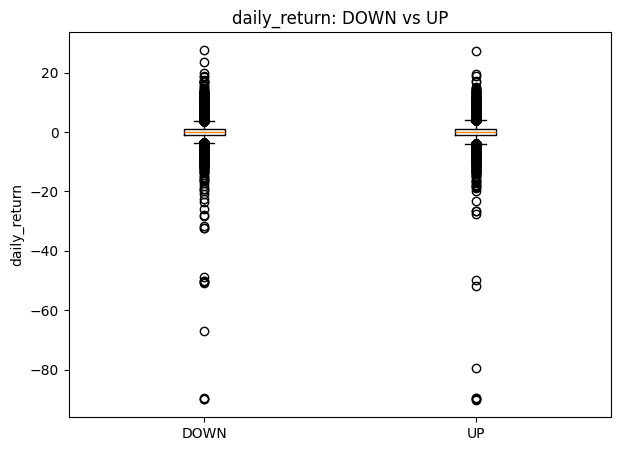

/tmp/ipykernel_31918/1041495270.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


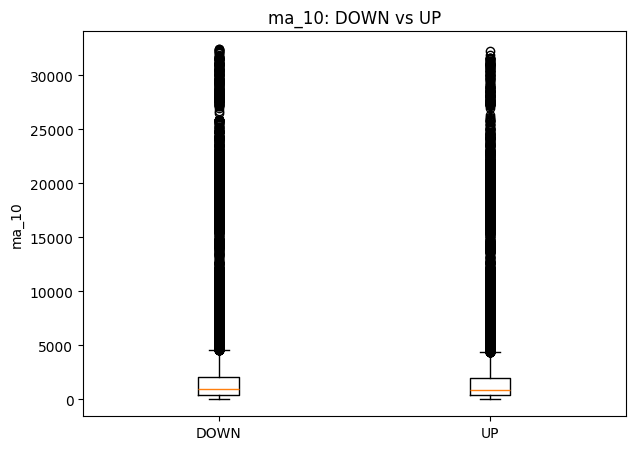

/tmp/ipykernel_31918/1041495270.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


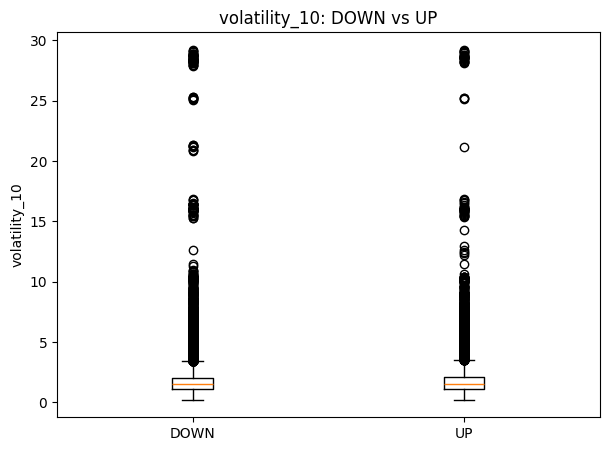

/tmp/ipykernel_31918/1041495270.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


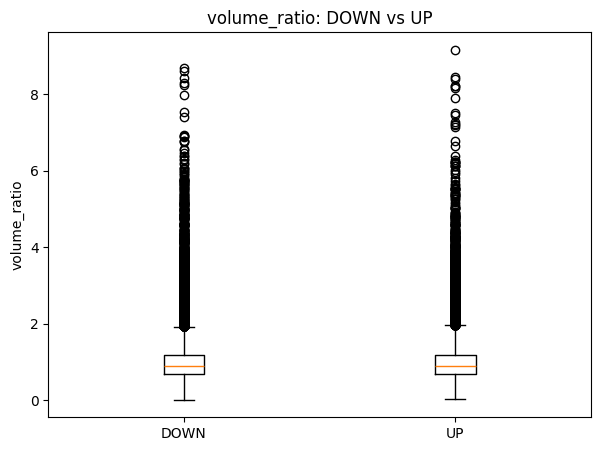

/tmp/ipykernel_31918/1041495270.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


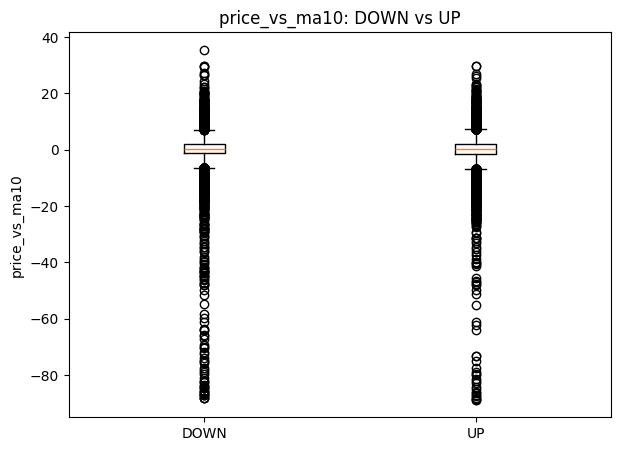

/tmp/ipykernel_31918/1041495270.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


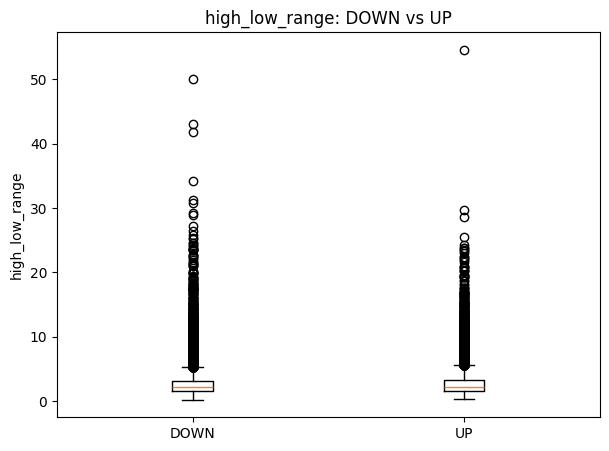

In [96]:
import matplotlib.pyplot as plt

# Create one boxplot for each feature
for feature in features_final:

    # Prepare DOWN and UP values
    down_values = train_final[
        train_final["target_025"] == 0
    ][feature]

    up_values = train_final[
        train_final["target_025"] == 1
    ][feature]

    # Create the plot
    plt.figure(figsize=(7, 5))

    plt.boxplot(
        [down_values, up_values],
        labels=["DOWN", "UP"]
    )

    # Add feature name as title
    plt.title(f"{feature}: DOWN vs UP")

    # Add y-axis label
    plt.ylabel(feature)

    # Show plot
    plt.show()

In [97]:
# Sort data by stock and date
df = df.sort_values(
    ["symbol", "timestamp"]
).copy()

# Create the previous trading day's return
df["daily_return_lag_1"] = (
    df.groupby("symbol")["daily_return"]
    .shift(1)
)

# Check the new feature
print(
    df[
        [
            "timestamp",
            "symbol",
            "daily_return",
            "daily_return_lag_1"
        ]
    ].head(20)
)

    timestamp    symbol  daily_return  daily_return_lag_1
10 2016-01-15  ADANIENT     -4.370180                 NaN
11 2016-01-18  ADANIENT     -5.779570           -4.370180
12 2016-01-19  ADANIENT      3.423680           -5.779570
13 2016-01-20  ADANIENT     -5.103448            3.423680
14 2016-01-21  ADANIENT      1.162791           -5.103448
15 2016-01-22  ADANIENT      5.962644            1.162791
16 2016-01-25  ADANIENT      0.474576            5.962644
17 2016-01-27  ADANIENT     -1.147099            0.474576
18 2016-01-28  ADANIENT     -1.638225           -1.147099
19 2016-01-29  ADANIENT      1.110340           -1.638225
20 2016-02-01  ADANIENT      2.333562            1.110340
21 2016-02-02  ADANIENT     -3.353454            2.333562
22 2016-02-03  ADANIENT     -0.138793           -3.353454
23 2016-02-04  ADANIENT      0.416956           -0.138793
24 2016-02-05  ADANIENT      2.006920            0.416956
25 2016-02-08  ADANIENT      2.442334            2.006920
26 2016-02-09 

In [98]:
# Create the return from 3 trading days ago
df["daily_return_lag_3"] = (
    df.groupby("symbol")["daily_return"]
    .shift(3)
)

# Check the new feature
print(
    df[
        [
            "timestamp",
            "symbol",
            "daily_return",
            "daily_return_lag_1",
            "daily_return_lag_3"
        ]
    ].head(20)
)

    timestamp    symbol  daily_return  daily_return_lag_1  daily_return_lag_3
10 2016-01-15  ADANIENT     -4.370180                 NaN                 NaN
11 2016-01-18  ADANIENT     -5.779570           -4.370180                 NaN
12 2016-01-19  ADANIENT      3.423680           -5.779570                 NaN
13 2016-01-20  ADANIENT     -5.103448            3.423680           -4.370180
14 2016-01-21  ADANIENT      1.162791           -5.103448           -5.779570
15 2016-01-22  ADANIENT      5.962644            1.162791            3.423680
16 2016-01-25  ADANIENT      0.474576            5.962644           -5.103448
17 2016-01-27  ADANIENT     -1.147099            0.474576            1.162791
18 2016-01-28  ADANIENT     -1.638225           -1.147099            5.962644
19 2016-01-29  ADANIENT      1.110340           -1.638225            0.474576
20 2016-02-01  ADANIENT      2.333562            1.110340           -1.147099
21 2016-02-02  ADANIENT     -3.353454            2.333562       

In [99]:
# Create the return from 5 trading days ago
df["daily_return_lag_5"] = (
    df.groupby("symbol")["daily_return"]
    .shift(5)
)

# Check all lagged return features
print(
    df[
        [
            "timestamp",
            "symbol",
            "daily_return",
            "daily_return_lag_1",
            "daily_return_lag_3",
            "daily_return_lag_5"
        ]
    ].head(20)
)

    timestamp    symbol  daily_return  daily_return_lag_1  daily_return_lag_3  \
10 2016-01-15  ADANIENT     -4.370180                 NaN                 NaN   
11 2016-01-18  ADANIENT     -5.779570           -4.370180                 NaN   
12 2016-01-19  ADANIENT      3.423680           -5.779570                 NaN   
13 2016-01-20  ADANIENT     -5.103448            3.423680           -4.370180   
14 2016-01-21  ADANIENT      1.162791           -5.103448           -5.779570   
15 2016-01-22  ADANIENT      5.962644            1.162791            3.423680   
16 2016-01-25  ADANIENT      0.474576            5.962644           -5.103448   
17 2016-01-27  ADANIENT     -1.147099            0.474576            1.162791   
18 2016-01-28  ADANIENT     -1.638225           -1.147099            5.962644   
19 2016-01-29  ADANIENT      1.110340           -1.638225            0.474576   
20 2016-02-01  ADANIENT      2.333562            1.110340           -1.147099   
21 2016-02-02  ADANIENT     

In [100]:
# Create a momentum feature using past returns
df["return_momentum"] = (
    df[
        [
            "daily_return_lag_1",
            "daily_return_lag_3",
            "daily_return_lag_5"
        ]
    ].mean(axis=1)
)

# Check the new momentum feature
print(
    df[
        [
            "timestamp",
            "symbol",
            "daily_return_lag_1",
            "daily_return_lag_3",
            "daily_return_lag_5",
            "return_momentum"
        ]
    ].head(15)
)

    timestamp    symbol  daily_return_lag_1  daily_return_lag_3  \
10 2016-01-15  ADANIENT                 NaN                 NaN   
11 2016-01-18  ADANIENT           -4.370180                 NaN   
12 2016-01-19  ADANIENT           -5.779570                 NaN   
13 2016-01-20  ADANIENT            3.423680           -4.370180   
14 2016-01-21  ADANIENT           -5.103448           -5.779570   
15 2016-01-22  ADANIENT            1.162791            3.423680   
16 2016-01-25  ADANIENT            5.962644           -5.103448   
17 2016-01-27  ADANIENT            0.474576            1.162791   
18 2016-01-28  ADANIENT           -1.147099            5.962644   
19 2016-01-29  ADANIENT           -1.638225            0.474576   
20 2016-02-01  ADANIENT            1.110340           -1.147099   
21 2016-02-02  ADANIENT            2.333562           -1.638225   
22 2016-02-03  ADANIENT           -3.353454            1.110340   
23 2016-02-04  ADANIENT           -0.138793            2.33356

In [101]:
# Select only the training period
momentum_train = df[
    df["timestamp"].dt.year <= 2023
].copy()

# Calculate correlation between momentum and target
momentum_corr = momentum_train[
    ["return_momentum", "target_025"]
].corr().loc[
    "return_momentum",
    "target_025"
]

# Display the result
print(
    "Return Momentum - Target Correlation:",
    momentum_corr
)

Return Momentum - Target Correlation: -0.022819562529174563


In [102]:
# Remove rows where momentum cannot be calculated
df_momentum = df.dropna(
    subset=["return_momentum"]
).copy()

# Check the new dataset shape
print("Momentum dataset shape:", df_momentum.shape)

# Check missing values in the momentum feature
print(
    "Missing momentum values:",
    df_momentum["return_momentum"].isna().sum()
)

Momentum dataset shape: (111690, 25)
Missing momentum values: 0


In [103]:
# Create training data from 2016–2023
momentum_train = df_momentum[
    df_momentum["timestamp"].dt.year <= 2023
].copy()

# Create validation data from 2024
momentum_val = df_momentum[
    df_momentum["timestamp"].dt.year == 2024
].copy()

# Create final test data from 2025
momentum_test = df_momentum[
    df_momentum["timestamp"].dt.year == 2025
].copy()

# Check the shapes
print("Momentum training shape:", momentum_train.shape)
print("Momentum validation shape:", momentum_val.shape)
print("Momentum test shape:", momentum_test.shape)

Momentum training shape: (87630, 25)
Momentum validation shape: (11952, 25)
Momentum test shape: (12108, 25)


In [104]:
# Add return_momentum to the existing 6 features
momentum_features = features.copy() + ["return_momentum"]

# Create training features and target
X_train_momentum = momentum_train[momentum_features]
y_train_momentum = momentum_train["target_025"]

# Create validation features and target
X_val_momentum = momentum_val[momentum_features]
y_val_momentum = momentum_val["target_025"]

# Create test features and target
X_test_momentum = momentum_test[momentum_features]
y_test_momentum = momentum_test["target_025"]

# Check the shapes
print("X_train_momentum:", X_train_momentum.shape)
print("y_train_momentum:", y_train_momentum.shape)

print("X_val_momentum:", X_val_momentum.shape)
print("y_val_momentum:", y_val_momentum.shape)

print("X_test_momentum:", X_test_momentum.shape)
print("y_test_momentum:", y_test_momentum.shape)

X_train_momentum: (87630, 7)
y_train_momentum: (87630,)
X_val_momentum: (11952, 7)
y_val_momentum: (11952,)
X_test_momentum: (12108, 7)
y_test_momentum: (12108,)


In [105]:
# Create the Random Forest for the momentum experiment
model_momentum_final = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

# Train only on 2016–2023 data
model_momentum_final.fit(
    X_train_momentum,
    y_train_momentum
)

print("Momentum model trained successfully.")

Momentum model trained successfully.


In [106]:
# Get UP probability on the 2024 validation set
y_prob_momentum_val = model_momentum_final.predict_proba(
    X_val_momentum
)[:, 1]

# Show first 20 probabilities
print(y_prob_momentum_val[:20])

[0.41  0.345 0.56  0.43  0.56  0.365 0.295 0.36  0.365 0.415 0.475 0.51
 0.33  0.455 0.485 0.46  0.55  0.425 0.405 0.495]


In [107]:
# Convert validation probabilities into predictions
y_pred_momentum_val = (
    y_prob_momentum_val >= 0.50
).astype(int)

# Calculate validation accuracy
momentum_val_accuracy = accuracy_score(
    y_val_momentum,
    y_pred_momentum_val
)

# Calculate validation ROC-AUC
momentum_val_roc_auc = roc_auc_score(
    y_val_momentum,
    y_prob_momentum_val
)

print("Momentum Validation Accuracy:", momentum_val_accuracy)
print(
    "Momentum Validation Accuracy (%):",
    momentum_val_accuracy * 100
)

print("Momentum Validation ROC-AUC:", momentum_val_roc_auc)

# Display classification report
print("\nClassification Report:")
print(
    classification_report(
        y_val_momentum,
        y_pred_momentum_val
    )
)

Momentum Validation Accuracy: 0.5481091030789826
Momentum Validation Accuracy (%): 54.81091030789826
Momentum Validation ROC-AUC: 0.4983024756686937

Classification Report:
              precision    recall  f1-score   support

           0       0.58      0.81      0.67      6883
           1       0.43      0.19      0.26      5069

    accuracy                           0.55     11952
   macro avg       0.50      0.50      0.47     11952
weighted avg       0.51      0.55      0.50     11952



In [109]:
# Calculate rolling return separately for each stock
df["rolling_return_3"] = (
    df.groupby("symbol")["daily_return"]
    .transform(
        lambda x: x.shift(1).rolling(3).sum()
    )
)

# Check the corrected feature
print(
    df[
        [
            "timestamp",
            "symbol",
            "daily_return",
            "rolling_return_3"
        ]
    ].head(15)
)

    timestamp    symbol  daily_return  rolling_return_3
10 2016-01-15  ADANIENT     -4.370180               NaN
11 2016-01-18  ADANIENT     -5.779570               NaN
12 2016-01-19  ADANIENT      3.423680               NaN
13 2016-01-20  ADANIENT     -5.103448         -6.726069
14 2016-01-21  ADANIENT      1.162791         -7.459338
15 2016-01-22  ADANIENT      5.962644         -0.516977
16 2016-01-25  ADANIENT      0.474576          2.021986
17 2016-01-27  ADANIENT     -1.147099          7.600011
18 2016-01-28  ADANIENT     -1.638225          5.290121
19 2016-01-29  ADANIENT      1.110340         -2.310748
20 2016-02-01  ADANIENT      2.333562         -1.674984
21 2016-02-02  ADANIENT     -3.353454          1.805677
22 2016-02-03  ADANIENT     -0.138793          0.090448
23 2016-02-04  ADANIENT      0.416956         -1.158684
24 2016-02-05  ADANIENT      2.006920         -3.075290


In [110]:
# Calculate correlation between 3-day rolling return and target
rolling_corr = df[
    ["rolling_return_3", "target_025"]
].corr().loc[
    "rolling_return_3",
    "target_025"
]

# Display the correlation
print(
    "3-Day Rolling Return - Target Correlation:",
    rolling_corr
)

3-Day Rolling Return - Target Correlation: -0.01049018421387936


In [111]:
# Create rolling return using the previous 5 trading days
df["rolling_return_5"] = (
    df.groupby("symbol")["daily_return"]
    .transform(
        lambda x: x.shift(1).rolling(5).sum()
    )
)

# Calculate correlation with the target
rolling_5_corr = df[
    ["rolling_return_5", "target_025"]
].corr().loc[
    "rolling_return_5",
    "target_025"
]

# Display the correlation
print(
    "5-Day Rolling Return - Target Correlation:",
    rolling_5_corr
)

5-Day Rolling Return - Target Correlation: -0.018760445108121224


In [112]:
# Create a summary of the major experiments
comparison = pd.DataFrame({
    "Experiment": [
        "Original Random Forest",
        "K-Means + Random Forest",
        "Momentum - Validation",
        "0.25% Target - Exploratory",
        "Balanced 0.25% - Exploratory",
        "Final 2025 Test"
    ],

    "Accuracy": [
        50.69,
        50.84,
        54.81,
        55.90,
        56.64,
        42.35
    ],

    "ROC_AUC": [
        np.nan,
        np.nan,
        49.83,
        np.nan,
        52.15,
        52.15
    ]
})

# Display the comparison
print(comparison)

                     Experiment  Accuracy  ROC_AUC
0        Original Random Forest     50.69      NaN
1       K-Means + Random Forest     50.84      NaN
2         Momentum - Validation     54.81    49.83
3    0.25% Target - Exploratory     55.90      NaN
4  Balanced 0.25% - Exploratory     56.64    52.15
5               Final 2025 Test     42.35    52.15
